Saving Huntington Disease Dataset.zip to Huntington Disease Dataset (2).zip
Dataset Loaded Successfully
                             Patient_ID  Age     Sex Family_History  \
0  b2a49170-8561-4665-9371-2240b55dd87a   31    Male             No   
1  f5fae45d-8718-41c4-a957-6928f79f3c8e   33  Female            Yes   
2  66ab0567-050b-4d56-9ec4-b676309899a6   69    Male            Yes   
3  996a48e4-e841-418f-a539-5a7a86cd815d   66    Male            Yes   
4  d45c7ca8-7125-4aaa-8018-5bbc60d35a1f   43  Female            Yes   

   HTT_CAG_Repeat_Length Motor_Symptoms Cognitive_Decline  Chorea_Score  \
0                     67       Moderate            Severe          8.80   
1                     38         Severe          Moderate          3.24   
2                     37         Severe          Moderate          1.01   
3                     50           Mild            Severe          3.21   
4                     48       Moderate              Mild          2.31   

   Brain_Volume_Lo

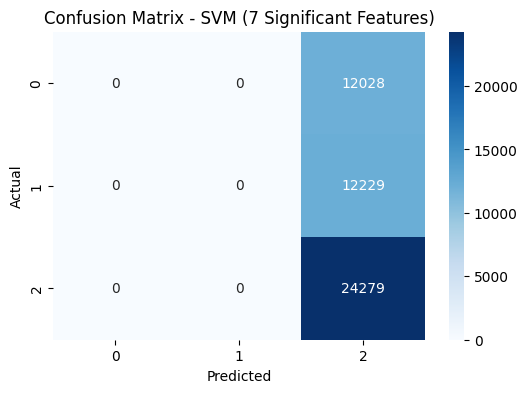

 FINAL ACCURACY OF ALGORITHM
Accuracy: 50.02%


In [6]:
import pandas as pd
import zipfile
import os
from google.colab import files
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Upload and Load Dataset
uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall("/content/")

csv_file = [f for f in os.listdir("/content/") if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join("/content/", csv_file))

print("Dataset Loaded Successfully")
print(df.head())


# Fill Missing Values
df = df.ffill()

# Select Significant Features

features = [
    'Age',
    'HTT_CAG_Repeat_Length',
    'Chorea_Score',
    'Brain_Volume_Loss',
    'Functional_Capacity',
    'Motor_Symptoms',
    'Cognitive_Decline'
]

X = df[features]

# Convert categorical variables to numeric
categorical_features = ['Motor_Symptoms', 'Cognitive_Decline']
for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Target Variable
target = 'Category'
y = df[target]
y = LabelEncoder().fit_transform(y)


# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Train SVM Model

model = SVC(kernel='linear', random_state=42)
model.fit(X_scaled, y)
y_pred = model.predict(X_scaled)


# Evaluation
print("\nAccuracy:", accuracy_score(y, y_pred))
print("\nClassification Report:\n", classification_report(y, y_pred))


# confusion matrix
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM (7 Significant Features)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Accuracy
final_accuracy = accuracy_score(y, y_pred)
print(" FINAL ACCURACY OF ALGORITHM")
print(f"Accuracy: {final_accuracy * 100:.2f}%")

